In [1]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── Detecção de pacotes disponíveis ─────────────────────────────────────────
try:
    import xgboost as xgb
    MODEL_BACKEND = "xgboost"
except ImportError:
    try:
        import lightgbm as lgb
        MODEL_BACKEND = "lightgbm"
    except ImportError:
        from sklearn.ensemble import GradientBoostingRegressor
        MODEL_BACKEND = "sklearn"

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

print(f"Backend do modelo : {MODEL_BACKEND}")
print(f"SHAP disponível   : {HAS_SHAP}")
print(f"{'─'*45}")
if not HAS_SHAP:
    print("⚠  shap não instalado — usando permutation attribution como proxy.")
    print("   Para SHAP exato: pip install shap xgboost\n")


Backend do modelo : sklearn
SHAP disponível   : False
─────────────────────────────────────────────
⚠  shap não instalado — usando permutation attribution como proxy.
   Para SHAP exato: pip install shap xgboost



In [2]:
pip install shap xgboost

   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   ---------------------------------------- 554.9/554.9 kB 3.8 MB/s  0:00:00
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 6.3 MB/s eta 0:00:16
    --------------------------------------- 2.1/101.7 MB 5.9 MB/s eta 0:00:17
   - -------------------------------------- 3.4/101.7 MB 5.9 MB/s eta 0:00:17
   - -------------------------------------- 4.7/101.7 MB 5.8 MB/s eta 0:00:17
   -- ------------------------------------- 6.0/101.7 MB 5.8 MB/s eta 0:00:17
   -- ------------------------------------- 7.1/101.7 MB 5.8 MB/s eta 0:00:17
   --- ------------------------------------ 8.4/101.7 MB 5.8 MB/s eta 0:00:17
   --- ------------------------------------ 9.4/101.7 MB 5.8 MB/s eta 0:00:17
   ---- ----------------------------------- 10.7/101.7 MB 5.8 MB/s eta 0:00:16
   ---- ----------------------------------- 12.1/101.7 MB 5.8 MB/s eta 0:00:16

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.15.0 requires numpy<2.0.0,>=1.23.5, but you have numpy 2.4.3 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

np.random.seed(42)

N_TRAIN_DAYS = 760   # ~2 anos de histórico
N_TEST_MONTHS = 3    # 3 meses de avaliação

FEATURES = [
    "dia_semana",    # 0=seg ... 6=dom
    "dia_mes",       # 1-31
    "semana_mes",    # 1-5
    "fim_semana",    # flag binária
    "fim_mes",       # últimos 6 dias do mês
    "promocao",      # flag binária (15% dos dias)
    "preco_index",   # índice relativo de preço (média=1.0)
    "estoque_flag",  # disponibilidade (90%)
    "temperatura",   # variável contínua sazonal
    "lag_7",         # venda 7 dias atrás
    "lag_14",        # venda 14 dias atrás
    "lag_28",        # venda 28 dias atrás
    "media_movel_7", # média móvel 7 dias
]

def gerar_features(dates: pd.DatetimeIndex) -> pd.DataFrame:
    df = pd.DataFrame({"date": dates})
    df["dia_semana"]   = df["date"].dt.dayofweek
    df["dia_mes"]      = df["date"].dt.day
    df["semana_mes"]   = ((df["dia_mes"] - 1) // 7 + 1).clip(1, 5)
    df["mes"]          = df["date"].dt.month
    df["fim_semana"]   = (df["dia_semana"] >= 5).astype(int)
    df["fim_mes"]      = (df["dia_mes"] >= 25).astype(int)
    df["promocao"]     = np.random.binomial(1, 0.15, len(df))
    df["preco_index"]  = np.clip(1.0 + np.random.normal(0, 0.05, len(df)), 0.8, 1.2)
    df["estoque_flag"] = np.random.binomial(1, 0.90, len(df))
    df["temperatura"]  = (
        20
        + 10 * np.sin(2 * np.pi * (df["mes"] - 1) / 12)
        + np.random.normal(0, 2, len(df))
    )
    # lags: preenchidos após geração de vendas
    for col in ["lag_7", "lag_14", "lag_28", "media_movel_7"]:
        df[col] = np.nan
    return df

def gerar_vendas(df: pd.DataFrame) -> np.ndarray:
    """Função de demanda com relações realistas entre features e volume."""
    ruido = np.random.normal(0, 8, len(df))
    tendencia = np.linspace(0, 20, len(df))  # crescimento secular
    vendas = (
        100
        + tendencia
        + 25  * df["promocao"]
        - 18  * df["fim_semana"]
        + 12  * (df["dia_semana"] == 0)   # pico de segunda
        + 8   * df["fim_mes"]
        - 40  * (df["preco_index"] - 1.0) # elasticidade de preço
        + 15  * df["estoque_flag"]
        + 1.5 * (df["temperatura"] - 20)
        + ruido
    ).clip(5)
    return vendas.values

def preencher_lags(df_all: pd.DataFrame, vendas_all: np.ndarray) -> pd.DataFrame:
    """Preenche lags e médias móveis com base no histórico completo."""
    df = df_all.copy()
    v = vendas_all
    n = len(df)
    lag7  = np.full(n, np.nan)
    lag14 = np.full(n, np.nan)
    lag28 = np.full(n, np.nan)
    mm7   = np.full(n, np.nan)
    for i in range(n):
        if i >= 7:  lag7[i]  = v[i - 7]
        if i >= 14: lag14[i] = v[i - 14]
        if i >= 28: lag28[i] = v[i - 28]
        if i >= 7:  mm7[i]   = v[max(0, i-7):i].mean()
    df["lag_7"]         = lag7
    df["lag_14"]        = lag14
    df["lag_28"]        = lag28
    df["media_movel_7"] = mm7
    return df

In [4]:
# ── Período total de dados ───────────────────────────────────────────────────
start_total = pd.Timestamp("2022-01-01")
n_total     = N_TRAIN_DAYS + N_TEST_MONTHS * 30 + 60  # buffer for dropna
dates_total = pd.date_range(start_total, periods=n_total, freq="D")

df_total         = gerar_features(dates_total)
df_total["vendas"] = gerar_vendas(df_total)
df_total           = preencher_lags(df_total, df_total["vendas"].values)
df_total           = df_total.dropna().reset_index(drop=True)

# ── Split treino / teste ─────────────────────────────────────────────────────
df_train = df_total.iloc[:N_TRAIN_DAYS].copy()

# Meses de teste: cada mês começa no dia 01 e vai até dia 30

test_months = []
for m in range(N_TEST_MONTHS):
    start = N_TRAIN_DAYS + m * 30
    end   = start + 30
    chunk = df_total.iloc[start:end].copy().reset_index(drop=True)
    test_months.append(chunk)

print(f"Treino: {len(df_train)} dias  ({df_train['date'].min().date()} → {df_train['date'].max().date()})")
for i, tm in enumerate(test_months):
    print(f"Teste mês {i+1}: {tm['date'].min().date()} → {tm['date'].max().date()}  ({len(tm)} dias)")
print()

X_train = df_train[FEATURES].values
y_train = df_train["vendas"].values

Treino: 760 dias  (2022-01-29 → 2024-02-27)
Teste mês 1: 2024-02-28 → 2024-03-28  (30 dias)
Teste mês 2: 2024-03-29 → 2024-04-27  (30 dias)
Teste mês 3: 2024-04-28 → 2024-05-27  (30 dias)



In [5]:

# ================================================================
# 2. TREINO DO MODELO
# ================================================================

def build_model():
    if MODEL_BACKEND == "xgboost":
        return xgb.XGBRegressor(
            n_estimators=400, learning_rate=0.05,
            max_depth=5, subsample=0.8,
            colsample_bytree=0.8, random_state=42,
            verbosity=0
        )
    elif MODEL_BACKEND == "lightgbm":
        return lgb.LGBMRegressor(
            n_estimators=400, learning_rate=0.05,
            num_leaves=31, random_state=42, verbose=-1
        )
    else:
        return GradientBoostingRegressor(
            n_estimators=400, learning_rate=0.05,
            max_depth=5, random_state=42
        )

model = build_model()
model.fit(X_train, y_train)
print(f"✅ Modelo treinado: {MODEL_BACKEND}\n")

✅ Modelo treinado: sklearn



In [18]:
def avaliar_mes(model, df_mes: pd.DataFrame) -> dict:
    """
    Recebe o DataFrame de 30 dias de um mês.
    Retorna dict com métricas, SHAP values e df de diagnóstico.
    """
    X_mes   = df_mes[FEATURES].values
    y_real  = df_mes["vendas"].values
    y_pred  = model.predict(X_mes)
    residual = y_pred - y_real   # positivo = superestimou

    # ── SHAP values dia a dia ─────────────────────────────────────────────
    print(f"  Calculando SHAP ({len(df_mes)} dias)...", end=" ", flush=True)
    shap_matrix = get_shap_values(model, X_mes)   # (30, n_features)
    print("✅")

    shap_df = pd.DataFrame(shap_matrix, columns=FEATURES)

    # ── Peso proporcional ao volume real ─────────────────────────────────
    weights = y_real / y_real.sum()

    # ── Métricas de erro do mês ───────────────────────────────────────────
    metricas = {
        "bias"    : float(np.mean(residual)),
        "mae"     : float(np.mean(np.abs(residual))),
        "mape"    : float(np.mean(np.abs(residual / y_real)) * 100),
        "rmse"    : float(np.sqrt(np.mean(residual ** 2))),
        "vol_real": float(y_real.sum()),
        "vol_pred": float(y_pred.sum()),
        "desvio_acum": float(y_pred.sum() - y_real.sum()),
    }

    # ── SHAP Error Contribution por feature ──────────────────────────────
    #    contribution_j = Σ_t [ shap_j(t) × residual(t) × weight(t) ]
    #    bias_feature_j = Σ_t [ shap_j(t) × weight(t) ]
    #    alignment_j    = Spearman( shap_j, residual )

    rows = []
    for feat in FEATURES:
        shap_j = shap_df[feat].values
        rows.append({
            "feature"     : feat,
            "contribution": float(np.sum(shap_j * residual * weights)),
            "error_impact": float(-1 * np.sum(shap_j * residual * weights) * np.sign(np.mean(residual))),
            "bias_feature": float(np.mean(shap_j)),
            "alignment"   : float(
                pd.Series(shap_j).corr(pd.Series(residual), method="spearman")
            ),
        })

    df_diag = (
        pd.DataFrame(rows)
        .set_index("feature")
        .sort_values("contribution", key=abs, ascending=False)
    )

    def diagnostico(row):
        c, b, a = row["contribution"], row["bias_feature"], row["alignment"]
        if abs(c) < 0.3:
            return "✅ Neutro"
        if b > 0.3 and a > 0.3:
            return "🔴 Inflando sistematicamente"
        if b < -0.3 and a > 0.3:
            return "🟠 Deflacionando — insuficiente"
        if abs(b) < 0.2 and abs(a) > 0.35:
            return "🟡 Volátil / instável"
        if a < -0.3:
            return "🔵 Agindo contra o erro"
        return "🟤 Impacto misto"

    df_diag["diagnostico"] = df_diag.apply(diagnostico, axis=1)

    return {
        "mes"      : df_mes["date"].iloc[0].strftime("%Y-%m"),
        "dates"    : df_mes["date"].values,
        "y_real"   : y_real,
        "y_pred"   : y_pred,
        "residual" : residual,
        "shap_df"  : shap_df,
        "metricas" : metricas,
        "df_diag"  : df_diag,
    }

print("Avaliando meses de teste:")
resultados = []
for i, df_mes in enumerate(test_months):
    print(f"  Mês {i+1} ({df_mes['date'].iloc[0].strftime('%Y-%m')}):")
    r = avaliar_mes(model, df_mes)
    resultados.append(r)

print()


Avaliando meses de teste:
  Mês 1 (2024-02):
  Calculando SHAP (30 dias)... ✅
  Mês 2 (2024-03):
  Calculando SHAP (30 dias)... ✅
  Mês 3 (2024-04):
  Calculando SHAP (30 dias)... ✅



FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/shap_attribution_2024-02.png'

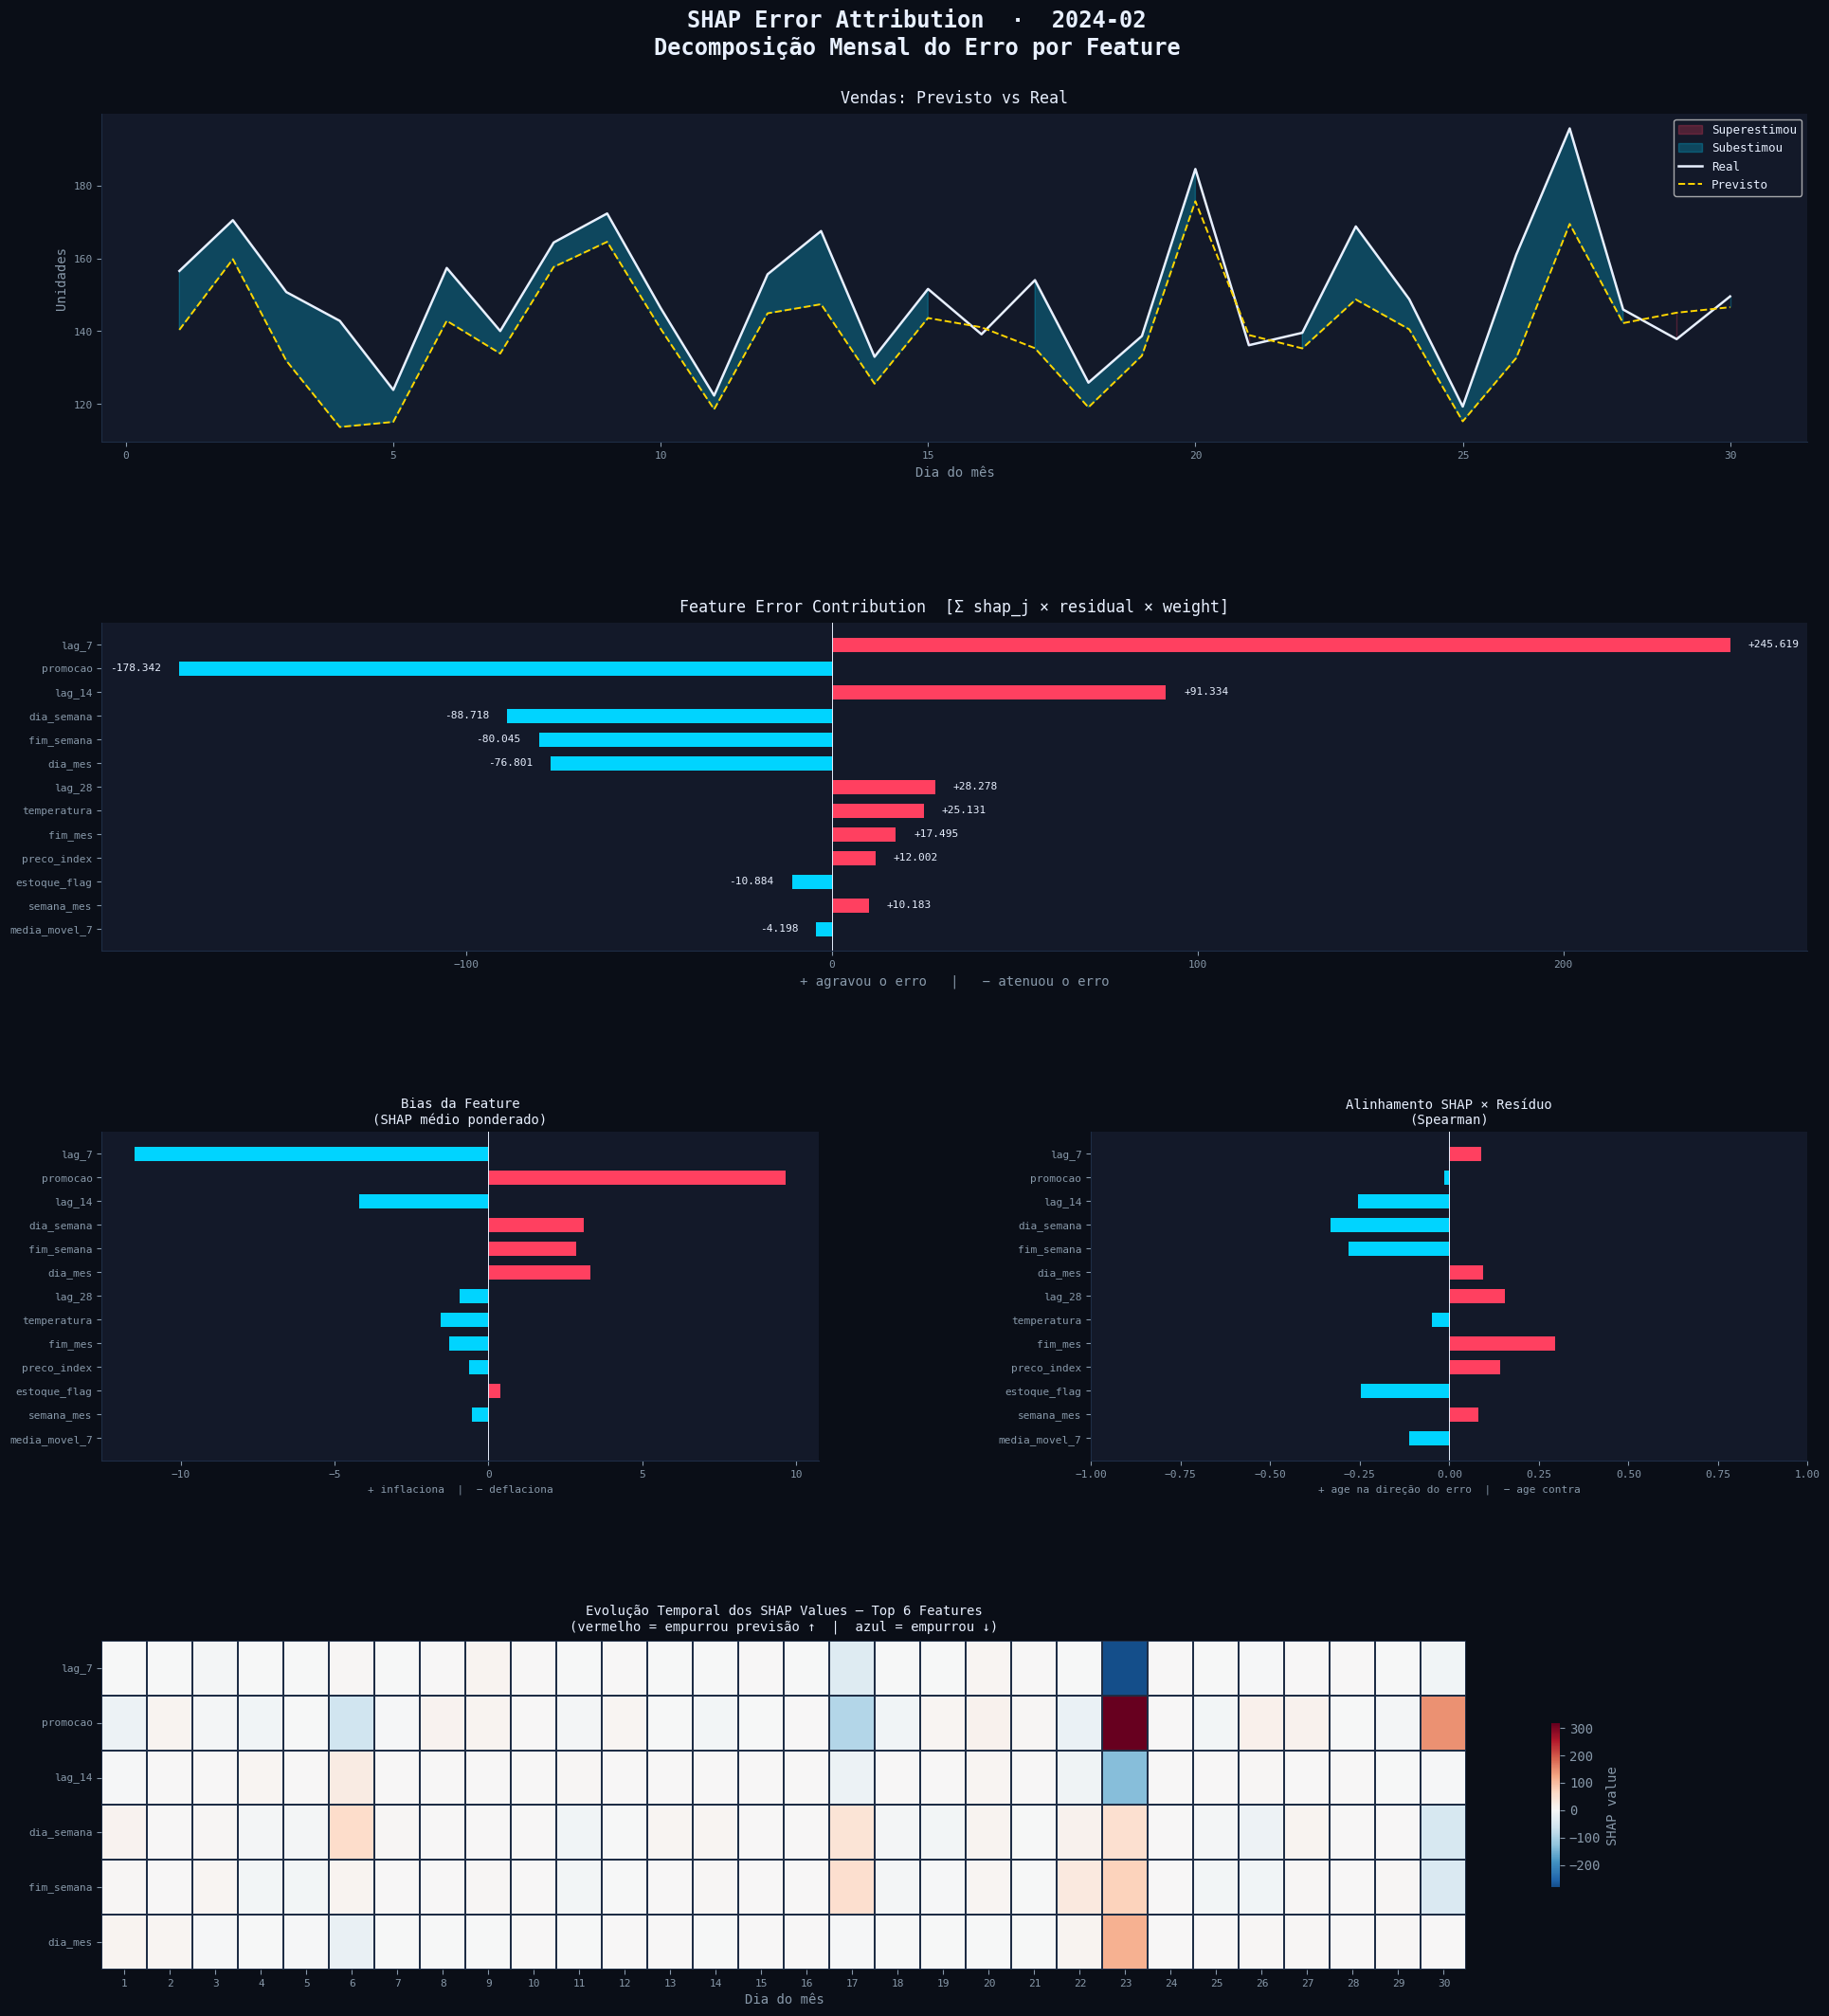

In [ ]:

BG      = "#0A0E17"
CARD    = "#131929"
BORDER  = "#1E2D45"
ACCENT  = "#00D4FF"
WARN    = "#FF4060"
GREEN   = "#00E676"
YELLOW  = "#FFD600"
NEUTRAL = "#8899AA"
WHITE   = "#E8F0FF"

plt.rcParams.update({
    "font.family": "monospace",
    "axes.facecolor": CARD,
    "figure.facecolor": BG,
    "text.color": WHITE,
    "axes.labelcolor": NEUTRAL,
    "xtick.color": NEUTRAL,
    "ytick.color": NEUTRAL,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def style_ax(ax, border=BORDER):
    for s in ax.spines.values():
        s.set_color(border)
    ax.tick_params(colors=NEUTRAL, labelsize=8)

# ── 5.1 Figura individual por mês ───────────────────────────────────────────
for res in resultados:
    mes       = res["mes"]
    residual  = res["residual"]
    y_real    = res["y_real"]
    y_pred    = res["y_pred"]
    shap_df   = res["shap_df"]
    df_diag   = res["df_diag"]
    m         = res["metricas"]
    days      = np.arange(1, 31)

    fig = plt.figure(figsize=(20, 22), facecolor=BG)
    fig.suptitle(
        f"SHAP Error Attribution  ·  {mes}\nDecomposição Mensal do Erro por Feature",
        fontsize=17, fontweight="bold", color=WHITE, y=0.98
    )

    gs = gridspec.GridSpec(
        4, 2, figure=fig,
        hspace=0.55, wspace=0.38,
        top=0.93, bottom=0.04, left=0.07, right=0.97
    )

    # KPI strip
    kpi_ax = fig.add_axes([0.07, 0.895, 0.90, 0.028])
    kpi_ax.set_facecolor(BORDER)
    kpi_ax.set_xlim(0, 1); kpi_ax.set_ylim(0, 1)
    kpi_ax.axis("off")
    kpis = [
        ("BIAS",  f"{m['bias']:+.1f} un"),
        ("MAE",   f"{m['mae']:.1f} un"),
        ("MAPE",  f"{m['mape']:.1f}%"),
        ("RMSE",  f"{m['rmse']:.1f} un"),
        ("VOL REAL",  f"{m['vol_real']:.0f}"),
        ("VOL PREV",  f"{m['vol_pred']:.0f}"),
        ("DESVIO",    f"{m['desvio_acum']:+.0f} un"),
    ]
    for k, (label, val) in enumerate(kpis):
        x = 0.02 + k * 0.137
        kpi_ax.text(x, 0.75, label, color=NEUTRAL, fontsize=7, fontweight="bold")
        color = WARN if (label in ("BIAS","DESVIO") and float(val.replace(" un","").replace("%","")) > 0) else ACCENT
        kpi_ax.text(x, 0.15, val,   color=color,   fontsize=9, fontweight="bold")

    # Plot 1: Previsão vs Real
    ax1 = fig.add_subplot(gs[0, :])
    ax1.fill_between(days, y_real, y_pred,
                     where=(y_pred >= y_real), color=WARN,   alpha=0.25, label="Superestimou")
    ax1.fill_between(days, y_real, y_pred,
                     where=(y_pred < y_real),  color=ACCENT, alpha=0.25, label="Subestimou")
    ax1.plot(days, y_real, color=WHITE,  linewidth=1.8, label="Real",    zorder=3)
    ax1.plot(days, y_pred, color=YELLOW, linewidth=1.4, label="Previsto",
             linestyle="--", zorder=3)
    ax1.set_title("Vendas: Previsto vs Real", color=WHITE, fontsize=12, pad=8)
    ax1.set_xlabel("Dia do mês"); ax1.set_ylabel("Unidades")
    ax1.legend(facecolor=CARD, labelcolor=WHITE, fontsize=9)
    style_ax(ax1)

    # Plot 2: Feature Error Contribution
    ax2 = fig.add_subplot(gs[1, :])
    feats_ord = df_diag.index.tolist()[::-1]
    vals_ord  = df_diag["contribution"].iloc[::-1].values
    colors_c  = [WARN if v > 0 else ACCENT for v in vals_ord]
    bars = ax2.barh(feats_ord, vals_ord, color=colors_c, edgecolor="none", height=0.6)
    ax2.axvline(0, color=WHITE, linewidth=0.7)
    ax2.set_title("Feature Error Contribution  [Σ shap_j × residual × weight]",
                  color=WHITE, fontsize=12, pad=8)
    ax2.set_xlabel("+ agravou o erro   |   − atenuou o erro")
    for bar, val in zip(bars, vals_ord):
        off = max(abs(vals_ord)) * 0.02
        ax2.text(val + (off if val >= 0 else -off),
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:+.3f}", va="center",
                 ha="left" if val >= 0 else "right",
                 color=WHITE, fontsize=8)
    style_ax(ax2)

    # Plot 3: Feature Bias
    ax3 = fig.add_subplot(gs[2, 0])
    bias_ord   = df_diag["bias_feature"].iloc[::-1].values
    colors_b   = [WARN if v > 0 else ACCENT for v in bias_ord]
    ax3.barh(feats_ord, bias_ord, color=colors_b, edgecolor="none", height=0.6)
    ax3.axvline(0, color=WHITE, linewidth=0.7)
    ax3.set_title("Bias da Feature\n(SHAP médio ponderado)", color=WHITE, fontsize=10, pad=6)
    ax3.set_xlabel("+ inflaciona  |  − deflaciona", fontsize=8)
    style_ax(ax3)

    # Plot 4: Alignment
    ax4 = fig.add_subplot(gs[2, 1])
    align_ord = df_diag["alignment"].iloc[::-1].values
    colors_a  = [WARN if v > 0 else ACCENT for v in align_ord]
    ax4.barh(feats_ord, align_ord, color=colors_a, edgecolor="none", height=0.6)
    ax4.axvline(0, color=WHITE, linewidth=0.7)
    ax4.set_xlim(-1, 1)
    ax4.set_title("Alinhamento SHAP × Resíduo\n(Spearman)", color=WHITE, fontsize=10, pad=6)
    ax4.set_xlabel("+ age na direção do erro  |  − age contra", fontsize=8)
    style_ax(ax4)

    # Plot 5: Heatmap temporal top-6
    ax5 = fig.add_subplot(gs[3, :])
    top6 = df_diag.head(6).index.tolist()
    sns.heatmap(
        shap_df[top6].T,
        ax=ax5, cmap="RdBu_r", center=0,
        linewidths=0.25, linecolor=BORDER,
        cbar_kws={"label": "SHAP value", "shrink": 0.5}
    )
    ax5.set_title(
        "Evolução Temporal dos SHAP Values — Top 6 Features\n"
        "(vermelho = empurrou previsão ↑  |  azul = empurrou ↓)",
        color=WHITE, fontsize=10, pad=8
    )
    ax5.set_xticklabels(days, fontsize=7, color=NEUTRAL)
    ax5.set_xlabel("Dia do mês"); ax5.tick_params(colors=NEUTRAL, labelsize=8)

    # plt.savefig(
    #     f"/mnt/user-data/outputs/shap_attribution_{mes}.png",
    #     dpi=150, bbox_inches="tight", facecolor=BG
    # )
    plt.close()
    print(f"✅ Figura salva: shap_attribution_{mes}.png")


# ── 5.2 Painel comparativo entre meses ──────────────────────────────────────
fig2, axes = plt.subplots(
    3, len(resultados), figsize=(8 * len(resultados), 16),
    facecolor=BG
)
fig2.suptitle(
    "Comparativo Mensal — SHAP Error Attribution",
    fontsize=16, fontweight="bold", color=WHITE, y=0.98
)

for col, res in enumerate(resultados):
    df_diag  = res["df_diag"]
    residual = res["residual"]
    days     = np.arange(1, 31)
    mes      = res["mes"]

    # Linha 0: resíduo diário
    ax = axes[0, col]
    ax.fill_between(days, residual, 0, where=(residual >= 0), color=WARN,   alpha=0.7)
    ax.fill_between(days, residual, 0, where=(residual <  0), color=ACCENT, alpha=0.7)
    ax.axhline(0,                    color=WHITE,  linewidth=0.7, linestyle="--")
    ax.axhline(np.mean(residual),    color=YELLOW, linewidth=1.2, linestyle=":",
               label=f"Bias: {np.mean(residual):+.1f}")
    ax.set_title(f"Resíduo Diário — {mes}", color=WHITE, fontsize=11)
    ax.legend(facecolor=CARD, labelcolor=WHITE, fontsize=8)
    style_ax(ax)

    # Linha 1: contribution
    ax = axes[1, col]
    top_feats = df_diag.head(8)
    feats_r   = top_feats.index.tolist()[::-1]
    vals_r    = top_feats["contribution"].iloc[::-1].values
    colors_c  = [WARN if v > 0 else ACCENT for v in vals_r]
    ax.barh(feats_r, vals_r, color=colors_c, edgecolor="none", height=0.6)
    ax.axvline(0, color=WHITE, linewidth=0.7)
    ax.set_title(f"Feature Contribution — {mes}", color=WHITE, fontsize=11)
    ax.set_xlabel("Contribuição ponderada")
    style_ax(ax)

    # Linha 2: diagnóstico tabular
    ax = axes[2, col]
    ax.axis("off")
    ax.set_facecolor(CARD)
    table_data = [
        [feat,
         f"{row['contribution']:+.3f}",
         f"{row['bias_feature']:+.3f}",
         row["diagnostico"]
        ]
        for feat, row in df_diag.iterrows()
    ]
    tbl = ax.table(
        cellText=table_data,
        colLabels=["Feature", "Contrib.", "Bias", "Diagnóstico"],
        cellLoc="center", loc="center",
        bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8)
    for (row_i, col_i), cell in tbl.get_celld().items():
        cell.set_facecolor(CARD if row_i % 2 == 0 else BORDER)
        cell.set_edgecolor(BORDER)
        cell.set_text_props(color=WHITE)
    ax.set_title(f"Diagnóstico — {mes}", color=WHITE, fontsize=11, pad=10)

plt.tight_layout(rect=[0, 0, 1, 0.97])
# plt.savefig(
#     "/mnt/user-data/outputs/shap_comparativo_mensal.png",
#     dpi=150, bbox_inches="tight", facecolor=BG
# )
# plt.close()
# print("✅ Figura salva: shap_comparativo_mensal.png\n")


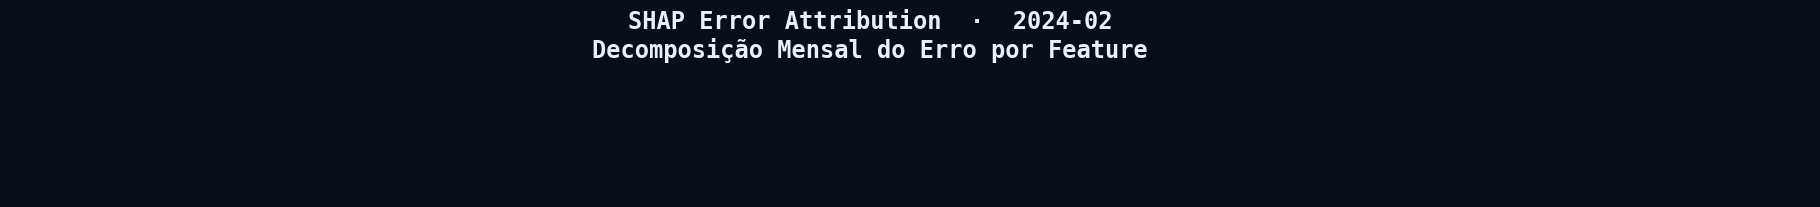

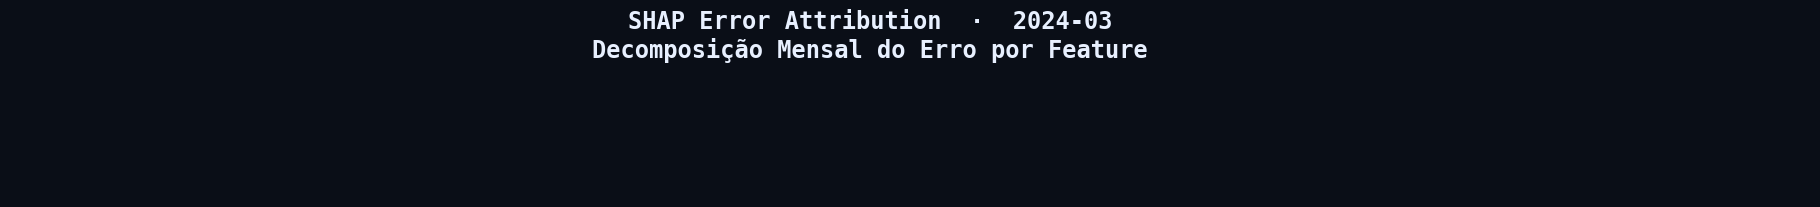

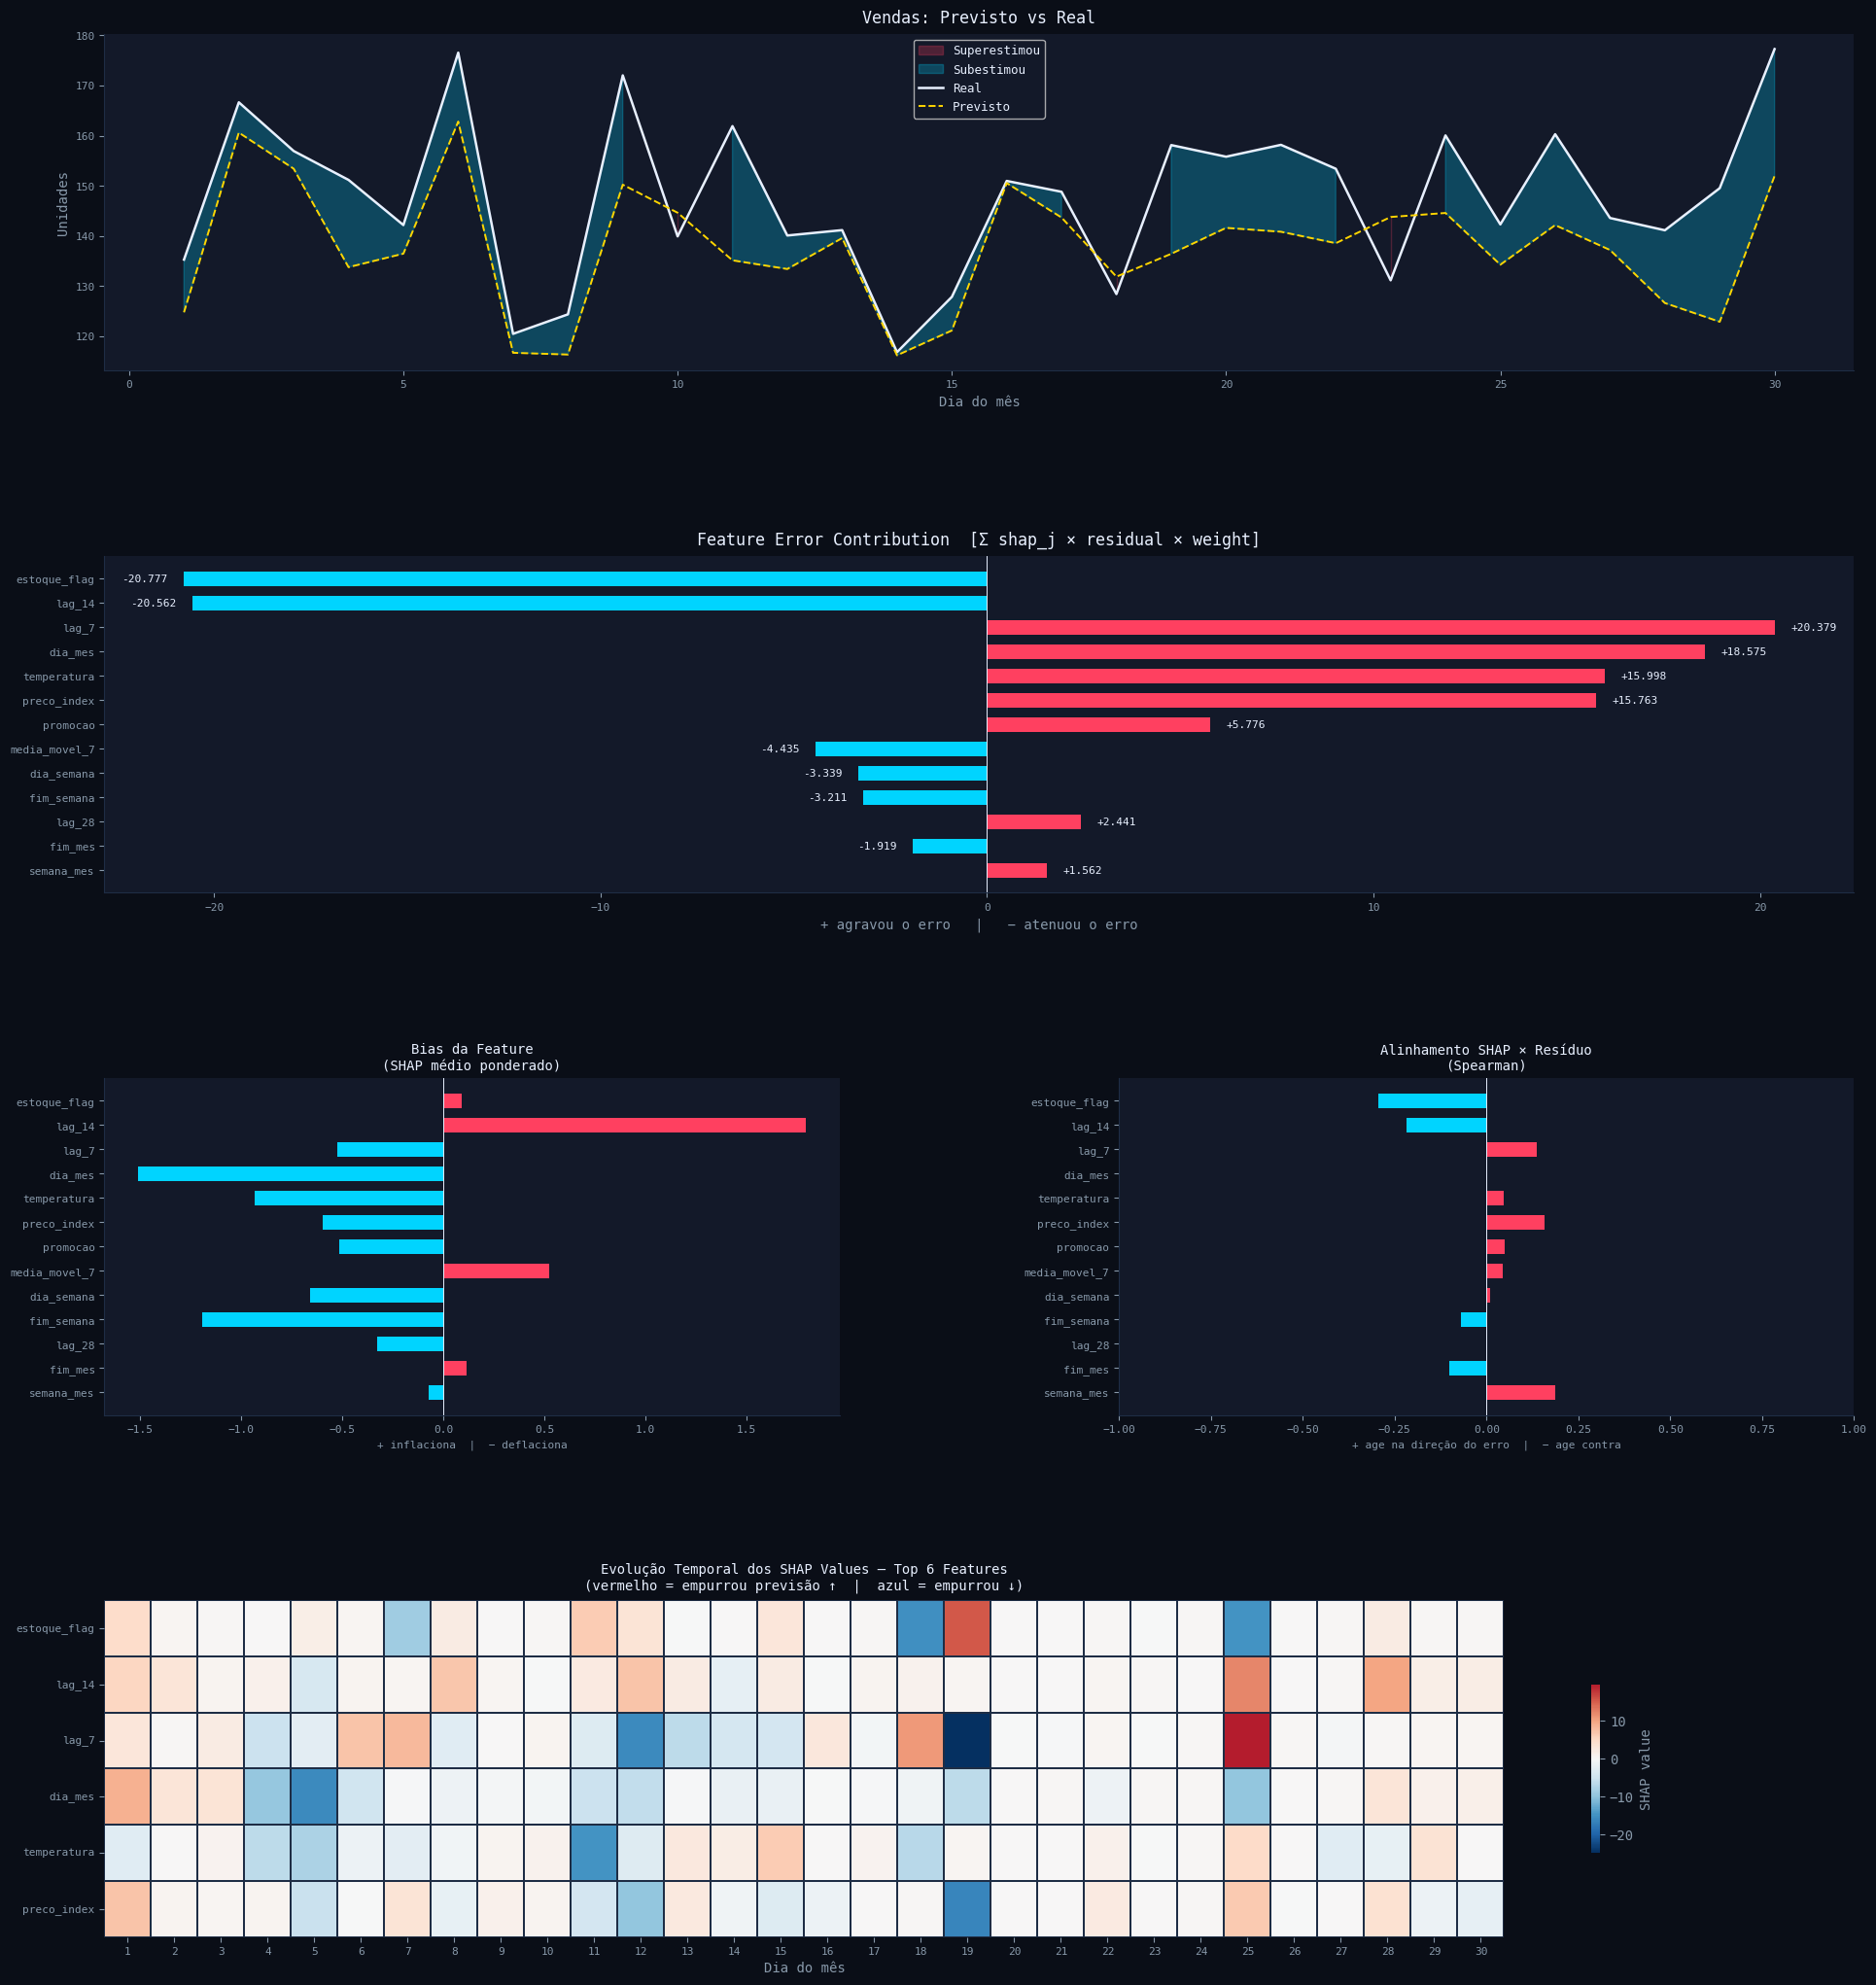

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [26]:

# ================================================================
# 5. VISUALIZAÇÕES — uma figura por mês + painel comparativo
# ================================================================

BG      = "#0A0E17"
CARD    = "#131929"
BORDER  = "#1E2D45"
ACCENT  = "#00D4FF"
WARN    = "#FF4060"
GREEN   = "#00E676"
YELLOW  = "#FFD600"
NEUTRAL = "#8899AA"
WHITE   = "#E8F0FF"

plt.rcParams.update({
    "font.family": "monospace",
    "axes.facecolor": CARD,
    "figure.facecolor": BG,
    "text.color": WHITE,
    "axes.labelcolor": NEUTRAL,
    "xtick.color": NEUTRAL,
    "ytick.color": NEUTRAL,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def style_ax(ax, border=BORDER):
    for s in ax.spines.values():
        s.set_color(border)
    ax.tick_params(colors=NEUTRAL, labelsize=8)

# ── 5.1 Figura individual por mês ───────────────────────────────────────────
for res in resultados:
    mes       = res["mes"]
    residual  = res["residual"]
    y_real    = res["y_real"]
    y_pred    = res["y_pred"]
    shap_df   = res["shap_df"]
    df_diag   = res["df_diag"]
    m         = res["metricas"]
    days      = np.arange(1, 31)

    fig = plt.figure(figsize=(20, 22), facecolor=BG)
    fig.suptitle(
        f"SHAP Error Attribution  ·  {mes}\nDecomposição Mensal do Erro por Feature",
        fontsize=17, fontweight="bold", color=WHITE, y=0.98
    )

    gs = gridspec.GridSpec(
        4, 2, figure=fig,
        hspace=0.55, wspace=0.38,
        top=0.93, bottom=0.04, left=0.07, right=0.97
    )

    # KPI strip
    kpi_ax = fig.add_axes([0.07, 0.895, 0.90, 0.028])
    kpi_ax.set_facecolor(BORDER)
    kpi_ax.set_xlim(0, 1); kpi_ax.set_ylim(0, 1)
    kpi_ax.axis("off")
    kpis = [
        ("BIAS",  f"{m['bias']:+.1f} un"),
        ("MAE",   f"{m['mae']:.1f} un"),
        ("MAPE",  f"{m['mape']:.1f}%"),
        ("RMSE",  f"{m['rmse']:.1f} un"),
        ("VOL REAL",  f"{m['vol_real']:.0f}"),
        ("VOL PREV",  f"{m['vol_pred']:.0f}"),
        ("DESVIO",    f"{m['desvio_acum']:+.0f} un"),
    ]
for k, (label, val) in enumerate(kpis):
    x = 0.02 + k * 0.137
    kpi_ax.text(x, 0.75, label, color=NEUTRAL, fontsize=7, fontweight="bold")
    color = WARN if (label in ("BIAS","DESVIO") and float(val.replace(" un","").replace("%","")) > 0) else ACCENT
    kpi_ax.text(x, 0.15, val,   color=color,   fontsize=9, fontweight="bold")

    plt.clf()
# Plot 1: Previsão vs Real
    ax1 = fig.add_subplot(gs[0, :])
    ax1.fill_between(days, y_real, y_pred,
                     where=(y_pred >= y_real), color=WARN,   alpha=0.25, label="Superestimou")
    ax1.fill_between(days, y_real, y_pred,
                     where=(y_pred < y_real),  color=ACCENT, alpha=0.25, label="Subestimou")
    ax1.plot(days, y_real, color=WHITE,  linewidth=1.8, label="Real",    zorder=3)
    ax1.plot(days, y_pred, color=YELLOW, linewidth=1.4, label="Previsto",
             linestyle="--", zorder=3)
    ax1.set_title("Vendas: Previsto vs Real", color=WHITE, fontsize=12, pad=8)
    ax1.set_xlabel("Dia do mês"); ax1.set_ylabel("Unidades")
    ax1.legend(facecolor=CARD, labelcolor=WHITE, fontsize=9)
    style_ax(ax1)

    # Plot 2: Feature Error Contribution
    ax2 = fig.add_subplot(gs[1, :])
    feats_ord = df_diag.index.tolist()[::-1]
    vals_ord  = df_diag["contribution"].iloc[::-1].values
    colors_c  = [WARN if v > 0 else ACCENT for v in vals_ord]
    bars = ax2.barh(feats_ord, vals_ord, color=colors_c, edgecolor="none", height=0.6)
    ax2.axvline(0, color=WHITE, linewidth=0.7)
    ax2.set_title("Feature Error Contribution  [Σ shap_j × residual × weight]",
                  color=WHITE, fontsize=12, pad=8)
    ax2.set_xlabel("+ agravou o erro   |   − atenuou o erro")
    for bar, val in zip(bars, vals_ord):
        off = max(abs(vals_ord)) * 0.02
        ax2.text(val + (off if val >= 0 else -off),
                 bar.get_y() + bar.get_height() / 2,
                 f"{val:+.3f}", va="center",
                 ha="left" if val >= 0 else "right",
                 color=WHITE, fontsize=8)
    style_ax(ax2)

    # Plot 3: Feature Bias
    ax3 = fig.add_subplot(gs[2, 0])
    bias_ord   = df_diag["bias_feature"].iloc[::-1].values
    colors_b   = [WARN if v > 0 else ACCENT for v in bias_ord]
    ax3.barh(feats_ord, bias_ord, color=colors_b, edgecolor="none", height=0.6)
    ax3.axvline(0, color=WHITE, linewidth=0.7)
    ax3.set_title("Bias da Feature\n(SHAP médio ponderado)", color=WHITE, fontsize=10, pad=6)
    ax3.set_xlabel("+ inflaciona  |  − deflaciona", fontsize=8)
    style_ax(ax3)

    # Plot 4: Alignment
    ax4 = fig.add_subplot(gs[2, 1])
    align_ord = df_diag["alignment"].iloc[::-1].values
    colors_a  = [WARN if v > 0 else ACCENT for v in align_ord]
    ax4.barh(feats_ord, align_ord, color=colors_a, edgecolor="none", height=0.6)
    ax4.axvline(0, color=WHITE, linewidth=0.7)
    ax4.set_xlim(-1, 1)
    ax4.set_title("Alinhamento SHAP × Resíduo\n(Spearman)", color=WHITE, fontsize=10, pad=6)
    ax4.set_xlabel("+ age na direção do erro  |  − age contra", fontsize=8)
    style_ax(ax4)

    # Plot 5: Heatmap temporal top-6
    ax5 = fig.add_subplot(gs[3, :])
    top6 = df_diag.head(6).index.tolist()
    sns.heatmap(
        shap_df[top6].T,
        ax=ax5, cmap="RdBu_r", center=0,
        linewidths=0.25, linecolor=BORDER,
        cbar_kws={"label": "SHAP value", "shrink": 0.5}
    )
    ax5.set_title(
        "Evolução Temporal dos SHAP Values — Top 6 Features\n"
        "(vermelho = empurrou previsão ↑  |  azul = empurrou ↓)",
        color=WHITE, fontsize=10, pad=8
    )
    ax5.set_xticklabels(days, fontsize=7, color=NEUTRAL)
    ax5.set_xlabel("Dia do mês"); ax5.tick_params(colors=NEUTRAL, labelsize=8)

    # plt.savefig(
    #     f"/mnt/user-data/outputs/shap_attribution_{mes}.png",
    #     dpi=150, bbox_inches="tight", facecolor=BG
    # )
    plt.show()
    # print(f"✅ Figura salva: shap_attribution_{mes}.png")
